In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
import pickle

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries imported successfully")

Libraries imported successfully


In [ ]:

df = pd.read_csv('/content/tertiary_final.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Dataset Shape: (11718, 16)
Columns: ['week', 'model_code', 'model_family', 'start_date', 'end_date', 'ret_stock', 'ret_dos', 'dbr_stock', 'dbr_dos', 'wod', 'stocking_outlet', 'activating_outlet', 'plc_factor', 'seasonality_1(sin)', 'seasonality_2(cos)', 'tertiary']


,week,model_code,model_family,start_date,end_date,ret_stock,ret_dos,dbr_stock,dbr_dos,wod,stocking_outlet,activating_outlet,plc_factor,seasonality_1(sin),seasonality_2(cos),tertiary
0,29,A1_CLEAR_COPPER,A1,2024-06-29 00:00:00+05:30,2024-06-30 00:00:00+05:30,35,17.5,3492,1746.0,11,17,4,100,0.053222,-0.998583,4.0
1,30,A1_CLEAR_COPPER,A1,2024-07-01 00:00:00+05:30,2024-07-07 00:00:00+05:30,0,0.0,0,0.0,174,0,21,100,-0.053222,-0.998583,34.0
2,31,A1_CLEAR_COPPER,A1,2024-07-08 00:00:00+05:30,2024-07-14 00:00:00+05:30,0,0.0,0,0.0,73,0,37,100,-0.159063,-0.987268,63.0
3,32,A1_CLEAR_COPPER,A1,2024-07-15 00:00:00+05:30,2024-07-21 00:00:00+05:30,0,0.0,0,0.0,18,0,36,100,-0.263103,-0.964768,56.0
4,33,A1_CLEAR_COPPER,A1,2024-07-22 00:00:00+05:30,2024-07-28 00:00:00+05:30,0,0.0,0,0.0,37,0,36,100,-0.364161,-0.931336,72.0


In [ ]:
import pandas as pd

df['start_date'] = pd.to_datetime(df['start_date'])
df['end_date'] = pd.to_datetime(df['end_date'])

df['year'] = df['start_date'].dt.year

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11718 entries, 0 to 11717
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype                    
---  ------              --------------  -----                    
 0   week                11718 non-null  int64                    
 1   model_code          11718 non-null  object                   
 2   model_family        11718 non-null  object                   
 3   start_date          11718 non-null  datetime64[ns, UTC+05:30]
 4   end_date            11718 non-null  datetime64[ns, UTC+05:30]
 5   ret_stock           11718 non-null  int64                    
 6   ret_dos             11718 non-null  float64                  
 7   dbr_stock           11718 non-null  int64                    
 8   dbr_dos             11718 non-null  float64                  
 9   wod                 11718 non-null  int64                    
 10  stocking_outlet     11718 non-null  int64                    
 11  activating_outl

In [ ]:

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
week                  0
model_code            0
model_family          0
start_date            0
end_date              0
ret_stock             0
ret_dos               0
dbr_stock             0
dbr_dos               0
wod                   0
stocking_outlet       0
activating_outlet     0
plc_factor            0
seasonality_1(sin)    0
seasonality_2(cos)    0
tertiary              0
year                  0
dtype: int64


In [ ]:
print(f"\nTarget Variable Statistics:")
print(df['tertiary'].describe())


Target Variable Statistics:
count    11718.000000
mean      1930.375320
std       6652.946317
min          0.000000
25%         12.000000
50%         88.000000
75%        615.000000
max      71894.000000
Name: tertiary, dtype: float64


In [ ]:

print(f"\nModel Families:")
print(df['model_family'].value_counts())


Model Families:
model_family
Blaze        2415
Hero         1449
Yuva         1418
A1           1286
A3            843
A7            780
Josh          665
Gem           574
Moto_FP       525
MotoA10       347
Agni          330
A5            297
Others_LS     291
A3_Power      236
Shark         138
4G             62
O3             32
A2             27
Bold            3
Name: count, dtype: int64


In [ ]:

numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

In [ ]:
df = df.drop_duplicates()

In [ ]:
df = df.sort_values(['model_family', 'week']).reset_index(drop=True)
df

,week,model_code,model_family,start_date,end_date,ret_stock,ret_dos,dbr_stock,dbr_dos,wod,stocking_outlet,activating_outlet,plc_factor,seasonality_1(sin),seasonality_2(cos),tertiary,year
0,1,LAVA_ACTION_4G,4G,2025-01-01 00:00:00+05:30,2025-01-07 00:00:00+05:30,54953,289.226316,17879,94.100000,3669,12922,995,100,1.062935e-01,0.994335,1334.0,2025
1,2,LAVA_ACTION_4G,4G,2025-01-08 00:00:00+05:30,2025-01-14 00:00:00+05:30,55034,275.170000,13391,66.955000,3052,15142,1045,100,2.113826e-01,0.977403,1401.0,2025
2,3,LAVA_ACTION_4G,4G,2025-01-15 00:00:00+05:30,2025-01-21 00:00:00+05:30,48515,221.529680,10350,47.260274,2008,16307,1282,100,3.140767e-01,0.949398,1538.0,2025
3,4,LAVA_ACTION_4G,4G,2025-01-22 00:00:00+05:30,2025-01-28 00:00:00+05:30,38013,210.016575,10981,60.668508,1039,15885,1087,100,4.132122e-01,0.910635,1273.0,2025
4,5,LAVA_ACTION_4G,4G,2025-01-29 00:00:00+05:30,2025-01-31 00:00:00+05:30,62187,447.388489,10935,78.669065,438,15885,376,100,5.076658e-01,0.861554,417.0,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11713,59,LZX415_YUVA_3,Yuva,2025-12-29 00:00:00+05:30,2025-12-31 00:00:00+05:30,1601,400.250000,66,16.500000,28,373,12,100,-2.449294e-16,1.000000,12.0,2025
11714,59,YUVA_3_128GB,Yuva,2025-12-29 00:00:00+05:30,2025-12-31 00:00:00+05:30,1537,768.500000,17,8.500000,4,422,6,100,-2.449294e-16,1.000000,7.0,2025
11715,59,BOLD_N1,Yuva,2025-12-29 00:00:00+05:30,2025-12-31 00:00:00+05:30,24,0.000000,0,0.000000,0,4,0,100,-2.449294e-16,1.000000,0.0,2025
11716,59,YUVA_SMART_2,Yuva,2025-12-29 00:00:00+05:30,2025-12-31 00:00:00+05:30,96490,208.401728,26562,57.369330,1328,18862,1188,100,-2.449294e-16,1.000000,1391.0,2025


In [ ]:
# df = df[df['model_family'].str.upper() == 'YUVA'].copy()
# print(f"YUVA family shape: {df.shape}")

In [ ]:
if 'Year' in df.columns:
    df['year'] = df['Year']

In [ ]:
# df.drop(columns=['Year'], inplace=True)

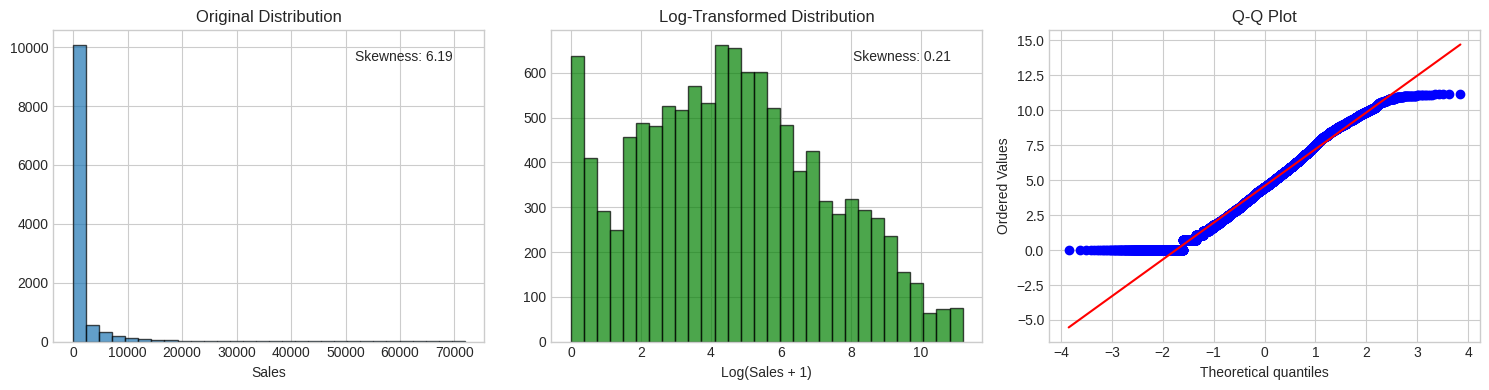

Original Skewness: 6.187
Log-Transformed Skewness: 0.208


In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['tertiary'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title('Original Distribution')
axes[0].set_xlabel('Sales')
skew_original = stats.skew(df['tertiary'])
axes[0].text(0.7, 0.9, f'Skewness: {skew_original:.2f}', transform=axes[0].transAxes)

log_tertiary = np.log1p(df['tertiary'])
axes[1].hist(log_tertiary, bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('Log-Transformed Distribution')
axes[1].set_xlabel('Log(Sales + 1)')
skew_log = stats.skew(log_tertiary)
axes[1].text(0.7, 0.9, f'Skewness: {skew_log:.2f}', transform=axes[1].transAxes)

stats.probplot(log_tertiary, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

print(f"Original Skewness: {skew_original:.3f}")
print(f"Log-Transformed Skewness: {skew_log:.3f}")


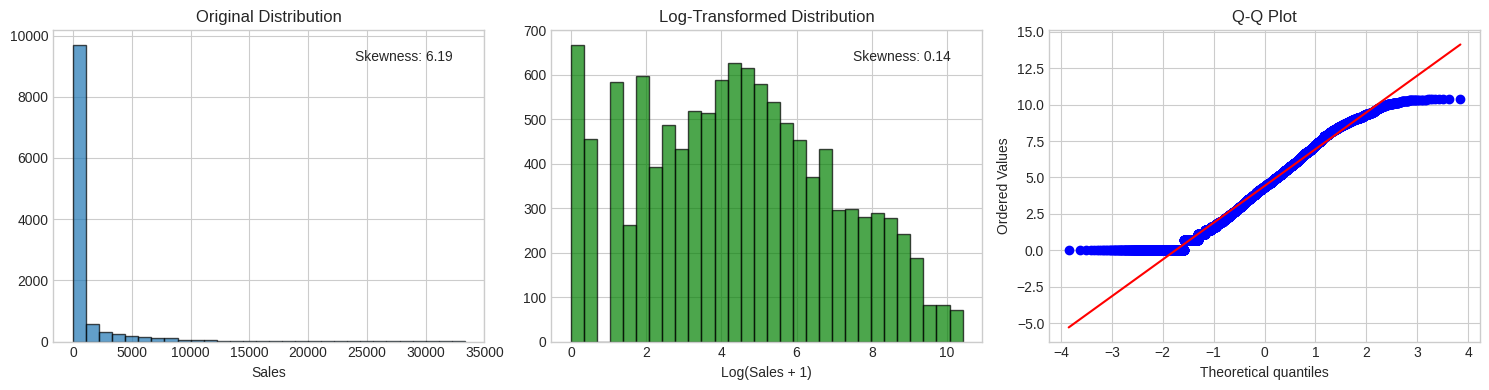

Original Skewness: 6.187
Log-Transformed Skewness: 0.144


In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['activating_outlet'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title('Original Distribution')
axes[0].set_xlabel('Sales')
skew_original = stats.skew(df['tertiary'])
axes[0].text(0.7, 0.9, f'Skewness: {skew_original:.2f}', transform=axes[0].transAxes)

log_tertiary = np.log1p(df['activating_outlet'])
axes[1].hist(log_tertiary, bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('Log-Transformed Distribution')
axes[1].set_xlabel('Log(Sales + 1)')
skew_log = stats.skew(log_tertiary)
axes[1].text(0.7, 0.9, f'Skewness: {skew_log:.2f}', transform=axes[1].transAxes)

stats.probplot(log_tertiary, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

print(f"Original Skewness: {skew_original:.3f}")
print(f"Log-Transformed Skewness: {skew_log:.3f}")


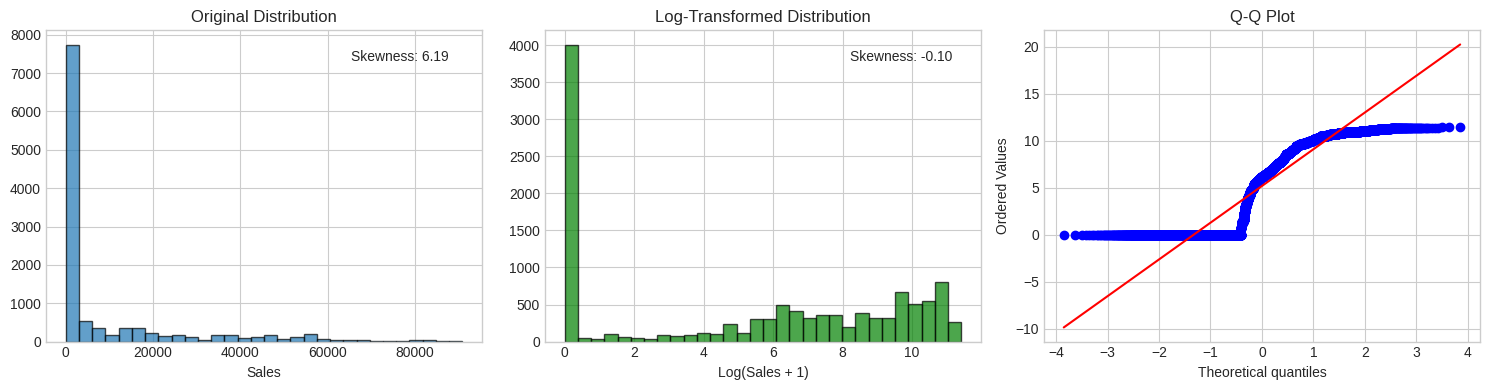

Original Skewness: 6.187
Log-Transformed Skewness: -0.102


In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['stocking_outlet'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title('Original Distribution')
axes[0].set_xlabel('Sales')
skew_original = stats.skew(df['tertiary'])
axes[0].text(0.7, 0.9, f'Skewness: {skew_original:.2f}', transform=axes[0].transAxes)

log_tertiary = np.log1p(df['stocking_outlet'])
axes[1].hist(log_tertiary, bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('Log-Transformed Distribution')
axes[1].set_xlabel('Log(Sales + 1)')
skew_log = stats.skew(log_tertiary)
axes[1].text(0.7, 0.9, f'Skewness: {skew_log:.2f}', transform=axes[1].transAxes)

stats.probplot(log_tertiary, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

print(f"Original Skewness: {skew_original:.3f}")
print(f"Log-Transformed Skewness: {skew_log:.3f}")


In [ ]:

df = df.sort_values('week').reset_index(drop=True)

FEATURE_COLUMNS = [
    'week', 'ret_stock', 'ret_dos','wod', 'activating_outlet',
]

FEATURE_COLUMNS2 = [
    'ret_stock', 'ret_dos', 'wod', 'activating_outlet',
]

TARGET_COLUMN = 'tertiary'

print(f"Total Features: {len(FEATURE_COLUMNS)}")
print(f"Features: {FEATURE_COLUMNS}")

Total Features: 5
Features: ['week', 'ret_stock', 'ret_dos', 'wod', 'activating_outlet']


In [ ]:
df.loc[:,["year"]].value_counts()

,count
year,
2025,7091
2024,4627


In [ ]:

df_2024 = df[df['year'] == 2024].copy()
df_2025 = df[df['year'] == 2025].sort_values('week').copy()

test_size = int(0.2 * len(df_2025))
if test_size == 0:
    test_size = max(1, len(df_2025))

df_test = df_2025.tail(test_size)
df_2025_train = df_2025.head(len(df_2025) - test_size)

df_train = pd.concat([df_2024, df_2025_train], ignore_index=True)

print(f"Training: {len(df_train)} records")
print(f"Testing: {len(df_test)} records")
if len(df_test) > 0:
    print(f"Test weeks: {df_test['week'].min()} to {df_test['week'].max()}")

Training: 10300 records
Testing: 1418 records
Test weeks: 49 to 59


## Linear Regression Model - Without Log transofrmation




In [ ]:
missing_cols = [col for col in FEATURE_COLUMNS if col not in df_train.columns]
if missing_cols:
    print(f"Warning: Missing columns removed: {missing_cols}")
    FEATURE_COLUMNS = [col for col in FEATURE_COLUMNS if col in df_train.columns]

X_train = df_train[FEATURE_COLUMNS].copy()
X_test = df_test[FEATURE_COLUMNS].copy()

y_train = df_train[TARGET_COLUMN].copy()
y_test = df_test[TARGET_COLUMN].copy()

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

y_train = np.clip(y_train, 0, None)
y_test = np.clip(y_test, 0, None)

# scaler = RobustScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Features: {len(FEATURE_COLUMNS)}")


X_train shape: (10300, 5)
X_test shape: (1418, 5)
Features: 5


In [ ]:

df

,week,model_code,model_family,start_date,end_date,ret_stock,ret_dos,dbr_stock,dbr_dos,wod,stocking_outlet,activating_outlet,plc_factor,seasonality_1(sin),seasonality_2(cos),tertiary,year
0,1,HERO_PUNCH_ONE,Hero,2024-01-01 00:00:00+05:30,2024-01-07 00:00:00+05:30,0,0.000000,0,0.000000,0,0,1,100,1.062935e-01,0.994335,1.0,2024
1,1,H6_HERO600I,Hero,2024-01-01 00:00:00+05:30,2024-01-07 00:00:00+05:30,0,0.000000,0,0.000000,555,0,11518,100,1.062935e-01,0.994335,17833.0,2024
2,1,H6_HERO_GLOW,Hero,2024-01-01 00:00:00+05:30,2024-01-07 00:00:00+05:30,0,0.000000,0,0.000000,10197,0,16108,100,1.062935e-01,0.994335,26624.0,2024
3,1,LAVA_A1_GOLD,A1,2025-01-01 00:00:00+05:30,2025-01-07 00:00:00+05:30,14114,0.000000,0,0.000000,0,8502,4,100,1.062935e-01,0.994335,4.0,2025
4,1,LF1008_A1_VIBE,A1,2025-01-01 00:00:00+05:30,2025-01-07 00:00:00+05:30,305248,229.337340,45508,34.190834,4260,64405,6225,100,1.062935e-01,0.994335,9321.0,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11713,59,YUVA_STAR_2,Yuva,2025-12-29 00:00:00+05:30,2025-12-31 00:00:00+05:30,62555,393.427673,6291,39.566038,406,14514,450,100,-2.449294e-16,1.000000,479.0,2025
11714,59,IL1802_MOTOA10E,MotoA10,2024-12-29 00:00:00+05:30,2024-12-31 00:00:00+05:30,40565,1014.125000,731,18.275000,5,23382,77,100,-2.449294e-16,1.000000,122.0,2024
11715,59,YUVA_SMART,Yuva,2024-12-29 00:00:00+05:30,2024-12-31 00:00:00+05:30,10490,43.347107,13716,56.677686,718,5163,569,100,-2.449294e-16,1.000000,726.0,2024
11716,59,LZX408_YUVA2PRO,Yuva,2024-12-29 00:00:00+05:30,2024-12-31 00:00:00+05:30,3663,366.300000,84,8.400000,20,2790,29,100,-2.449294e-16,1.000000,31.0,2024


In [ ]:
y_test

,tertiary
9423,24.0
9424,5.0
9425,49.0
9426,53.0
9427,1.0
...,...
11711,0.0
11712,111.0
11713,479.0
11663,1.0


In [ ]:

def calculate_metrics(y_true, y_pred, model_name="Model"):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    denominator = np.clip(np.abs(y_true), 1, None)
    mape = np.mean(np.abs((y_true - y_pred) / denominator)) * 100

    accuracy = max(0, 100 - mape)

    return {
        'Model': model_name,
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'Accuracy': accuracy
    }

print("Metrics function defined")

Metrics function defined


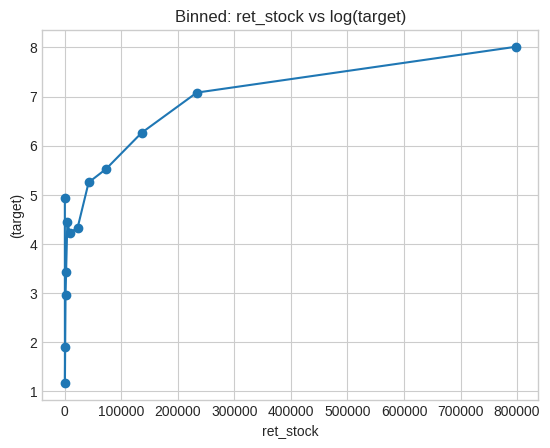

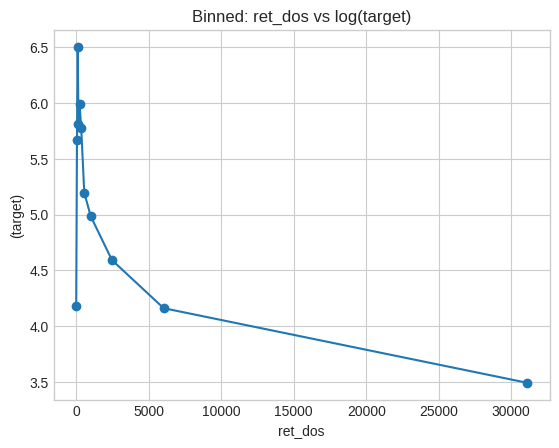

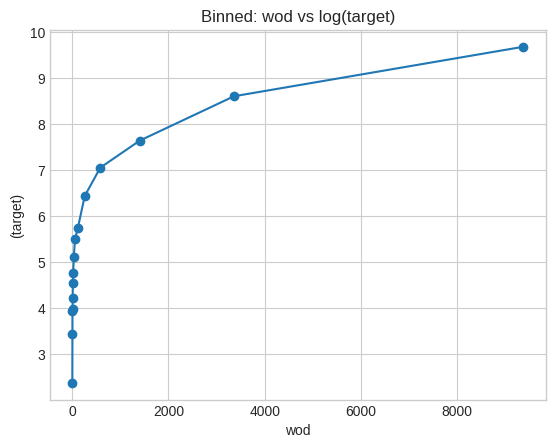

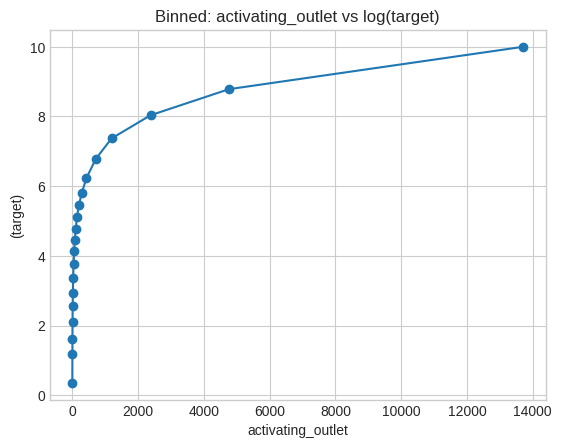

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

for col in FEATURE_COLUMNS2[:10]:
    df = pd.DataFrame({
        "x": X_train[col],
        "y": np.log1p(y_train)
    })

    df["bin"] = pd.qcut(df["x"], q=20, duplicates="drop")
    grouped = df.groupby("bin").mean()

    plt.figure()
    plt.plot(grouped["x"], grouped["y"], marker="o")
    plt.xlabel(col)
    plt.ylabel("(target)")
    plt.title(f"Binned: {col} vs log(target)")
    plt.show()


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import RobustScaler
import numpy as np

print("Training Linear Regression...")

lr_model = LinearRegression()
lr_model.fit(X_train, y_train_log)

lr_pred_log = lr_model.predict(X_test)
lr_pred = np.expm1(lr_pred_log)
lr_pred = np.clip(lr_pred, 0, None)

# Metrics
metrics_lr = calculate_metrics(y_test_log, lr_pred, "LinearRegression")

print("Linear Regression trained successfully")


Training Linear Regression...
Linear Regression trained successfully


In [ ]:



print("LINEAR REGRESSION MODEL RESULTS")
print(f"R2 Score:   {metrics_lr['R2']:.4f}")
print(f"MAE:        {metrics_lr['MAE']:.2f}")
print(f"RMSE:       {metrics_lr['RMSE']:.2f}")
print(f"MAPE:       {metrics_lr['MAPE']:.2f}%")
print(f"Accuracy:   {metrics_lr['Accuracy']:.2f}%")


LINEAR REGRESSION MODEL RESULTS
R2 Score:   -7001370936876.0713
MAE:        380199.49
RMSE:       7312357.51
MAPE:       3567561.07%
Accuracy:   0.00%


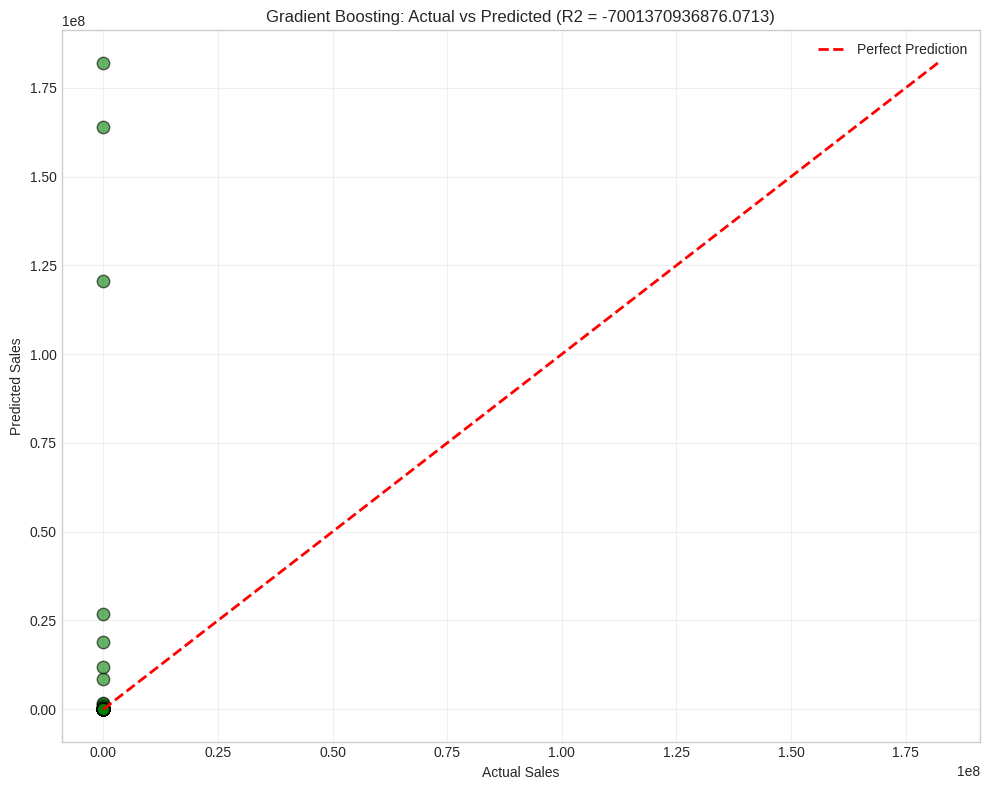

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(y_test, lr_pred, alpha=0.6, edgecolors='black', s=80, color='green')
max_val = max(y_test.max(), max(lr_pred)) if len(y_test) > 0 else 1
ax.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Sales')
ax.set_ylabel('Predicted Sales')
ax.set_title(f'Gradient Boosting: Actual vs Predicted (R2 = {metrics_lr["R2"]:.4f})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

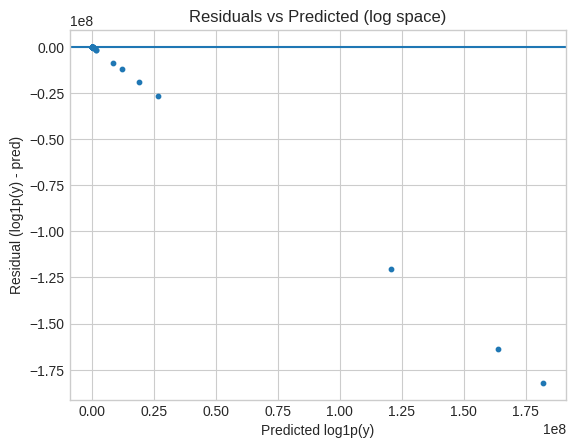

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


y_test_log = np.log1p(y_test)
res = y_test_log - lr_pred

plt.figure()
plt.scatter(lr_pred, res, s=10)
plt.axhline(0)
plt.xlabel("Predicted log1p(y)")
plt.ylabel("Residual (log1p(y) - pred)")
plt.title("Residuals vs Predicted (log space)")
plt.show()


## Linear Regression Model - With Log transofrmation


In [ ]:
# X_train["stocking_outlet"]=np.log1p(X_train["stocking_outlet"])
X_train["activating_outlet"]=np.log1p(X_train["activating_outlet"])
# X_train["dbr_stock"]=np.log1p(X_train["dbr_stock"])
# X_train["dbr_dos"]=np.log1p(X_train["dbr_dos"])
X_train["ret_stock"]=np.log1p(X_train["ret_stock"])
X_train["wod"]=np.log1p(X_train["wod"])
X_train["ret_dos"]=np.log1p(X_train["ret_dos"])


# X_test["stocking_outlet"]=np.log1p(X_test["stocking_outlet"])
X_test["activating_outlet"]=np.log1p(X_test["activating_outlet"])
# X_test["dbr_stock"]=np.log1p(X_test["dbr_stock"])
# X_test["dbr_dos"]=np.log1p(X_test["dbr_dos"])
X_test["ret_stock"]=np.log1p(X_test["ret_stock"])
X_test["wod"]=np.log1p(X_test["wod"])
X_test["ret_dos"]=np.log1p(X_test["ret_dos"])

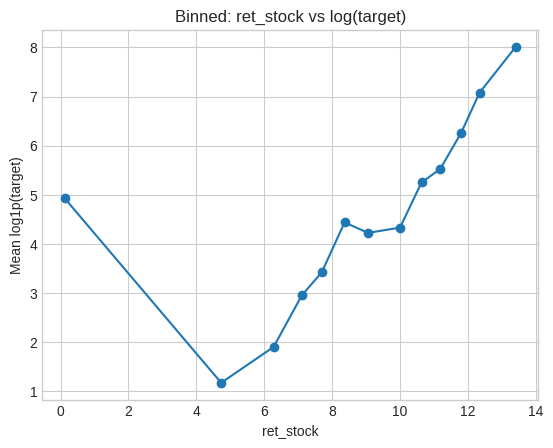

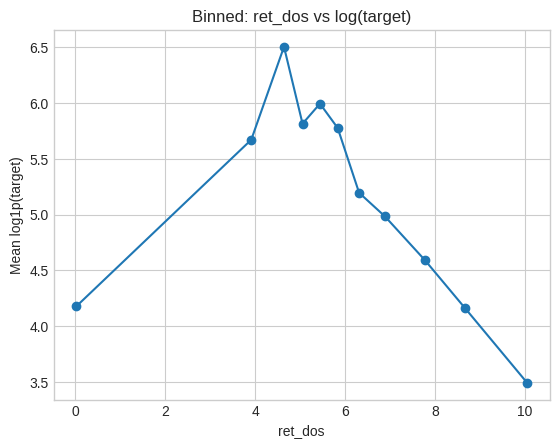

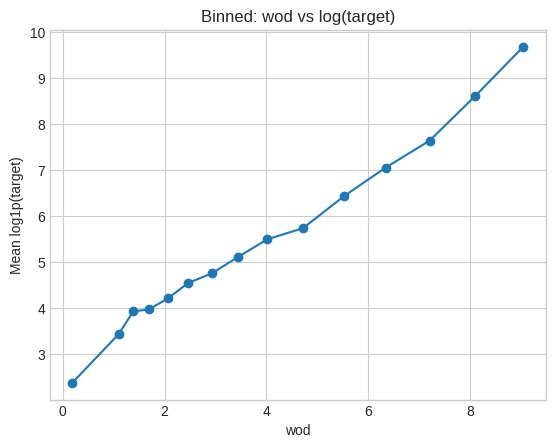

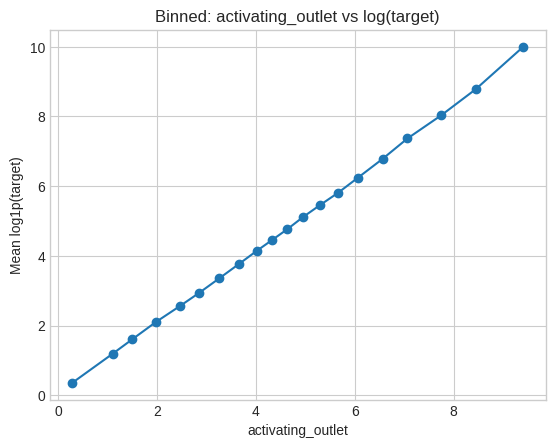

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

for col in FEATURE_COLUMNS2[:10]:
    df = pd.DataFrame({
        "x": X_train[col],
        "y": np.log1p(y_train)
    })

    df["bin"] = pd.qcut(df["x"], q=20, duplicates="drop")
    grouped = df.groupby("bin").mean()

    plt.figure()
    plt.plot(grouped["x"], grouped["y"], marker="o")
    plt.xlabel(col)
    plt.ylabel("Mean log1p(target)")
    plt.title(f"Binned: {col} vs log(target)")
    plt.show()


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import RobustScaler
import numpy as np

print("Training Linear Regression...")

lr_model = LinearRegression()
lr_model.fit(X_train, y_train_log)

# Predict (log space -> original)
lr_pred_log = lr_model.predict(X_test)
lr_pred = np.expm1(lr_pred_log)
# Metrics
metrics_lr = calculate_metrics(y_test, lr_pred, "LinearRegression")

print("Linear Regression trained successfully")


Training Linear Regression...
Linear Regression trained successfully


In [ ]:


print("LINEAR REGRESSION MODEL RESULTS")
print(f"R2 Score:   {metrics_lr['R2']:.4f}")
print(f"MAE:        {metrics_lr['MAE']:.2f}")
print(f"RMSE:       {metrics_lr['RMSE']:.2f}")
print(f"MAPE:       {metrics_lr['MAPE']:.2f}%")
print(f"Accuracy:   {metrics_lr['Accuracy']:.2f}%")


LINEAR REGRESSION MODEL RESULTS
R2 Score:   0.9770
MAE:        155.65
RMSE:       635.72
MAPE:       11.46%
Accuracy:   88.54%


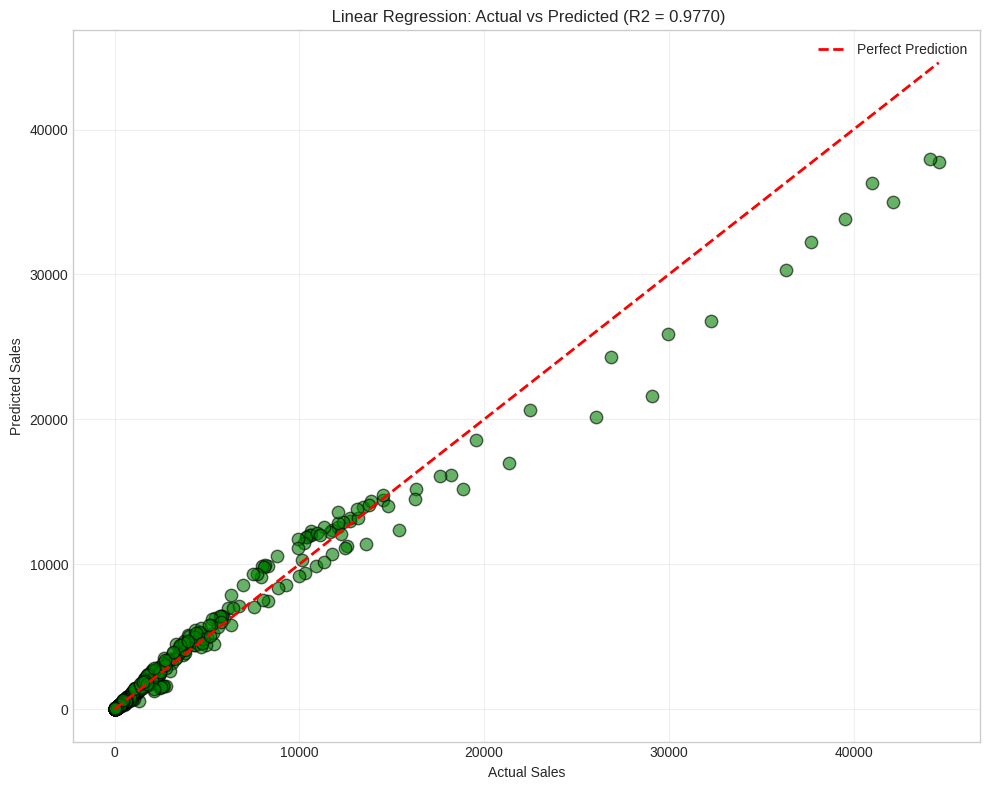

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(y_test, lr_pred, alpha=0.6, edgecolors='black', s=80, color='green')
max_val = max(y_test.max(), max(lr_pred)) if len(y_test) > 0 else 1
ax.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Sales')
ax.set_ylabel('Predicted Sales')
ax.set_title(f' Linear Regression: Actual vs Predicted (R2 = {metrics_lr["R2"]:.4f})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

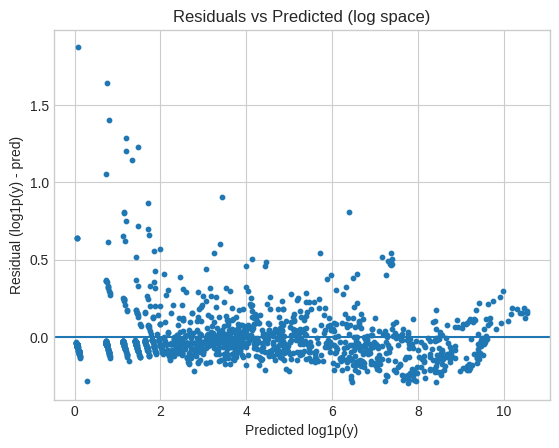

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


y_test_log = np.log1p(y_test)
res = y_test_log - lr_pred_log

plt.figure()
plt.scatter(lr_pred_log, res, s=10)
plt.axhline(0)
plt.xlabel("Predicted log1p(y)")
plt.ylabel("Residual (log1p(y) - pred)")
plt.title("Residuals vs Predicted (log space)")
plt.show()


## Polynomial Regression

In [ ]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

print("Training Polynomial Regression (degree=2, no scaling, no ridge)...")

X_train_poly = X_train.copy().fillna(0)
X_test_poly  = X_test.copy().fillna(0)

# Log target
y_train_log = np.log1p(y_train)

poly_model = Pipeline(steps=[
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("lr", LinearRegression())
])

poly_model.fit(X_train_poly, y_train_log)

poly_pred_log = poly_model.predict(X_test_poly)
poly_pred = np.expm1(poly_pred_log)
poly_pred = np.clip(poly_pred, 0, None)

metrics_poly = calculate_metrics(y_test, poly_pred, "PolynomialRegression_deg2_NoRidge_NoScaling")

print("Polynomial Regression trained successfully")


Training Polynomial Regression (degree=2, no scaling, no ridge)...
Polynomial Regression trained successfully


In [ ]:


print("LINEAR REGRESSION MODEL RESULTS")
print(f"R2 Score:   {metrics_poly['R2']:.4f}")
print(f"MAE:        {metrics_poly['MAE']:.2f}")
print(f"RMSE:       {metrics_poly['RMSE']:.2f}")
print(f"MAPE:       {metrics_poly['MAPE']:.2f}%")
print(f"Accuracy:   {metrics_poly['Accuracy']:.2f}%")


LINEAR REGRESSION MODEL RESULTS
R2 Score:   0.9870
MAE:        113.80
RMSE:       478.07
MAPE:       9.80%
Accuracy:   90.20%


In [ ]:
import joblib

artifact = {
    "model": poly_model,
    "features": X_train.columns.tolist()
}

joblib.dump(artifact, "linear_regression_tertiary_model.pkl")

['linear_regression_tertiary_model.pkl']

In [ ]:
model = joblib.load("/content/linear_regression_tertiary_model.pkl")

In [ ]:
model = artifact["model"]
features = artifact["features"]

# X_test_aligned = X_test.reindex(columns=features, fill_value=0)

pred_log = model.predict(X_test)
pred = np.expm1(pred_log)
pred = np.clip(pred, 0, None)

metrics = calculate_metrics(y_test, pred, "GB_Loaded_Artifact")
print(metrics)

{'Model': 'GB_Loaded_Artifact', 'R2': 0.9869774667010431, 'MAE': 113.80049235784674, 'RMSE': np.float64(478.0651976073678), 'MAPE': np.float64(9.803199738146091), 'Accuracy': np.float64(90.19680026185391)}


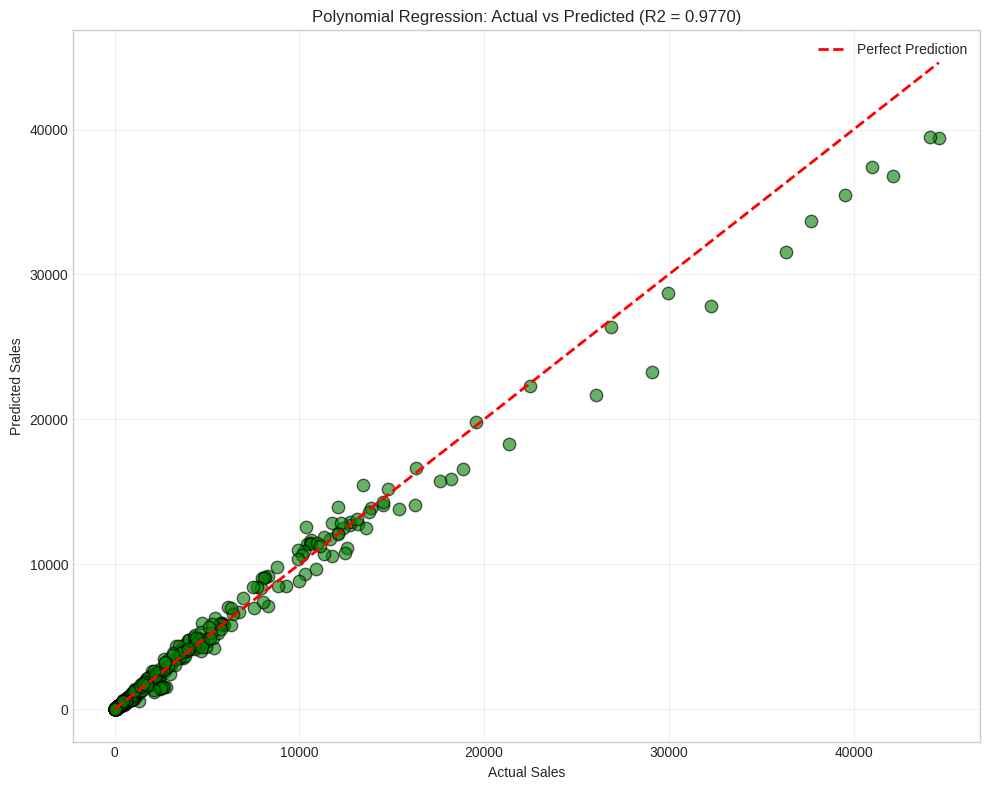

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(y_test, poly_pred, alpha=0.6, edgecolors='black', s=80, color='green')
max_val = max(y_test.max(), max(poly_pred)) if len(y_test) > 0 else 1
ax.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Sales')
ax.set_ylabel('Predicted Sales')
ax.set_title(f'Polynomial Regression: Actual vs Predicted (R2 = {metrics_lr["R2"]:.4f})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

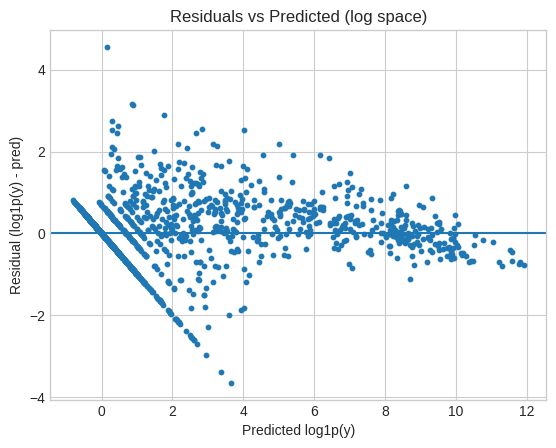

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


y_test_log = np.log1p(y_test)
res = y_test_log - poly_pred_log

plt.figure()
plt.scatter(poly_pred_log, res, s=10)
plt.axhline(0)
plt.xlabel("Predicted log1p(y)")
plt.ylabel("Residual (log1p(y) - pred)")
plt.title("Residuals vs Predicted (log space)")
plt.show()


## Gradient Boosting

In [ ]:
print("Training Gradient Boosting...")

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.06,
    subsample=0.8,
    random_state=42
)

gb_model.fit(X_train, y_train_log)

gb_pred_log = gb_model.predict(X_test)
gb_pred = np.expm1(gb_pred_log)
gb_pred = np.clip(gb_pred, 0, None)

metrics = calculate_metrics(y_test, gb_pred, "GradientBoosting")

print("Gradient Boosting trained successfully")

Training Gradient Boosting...
Gradient Boosting trained successfully


In [ ]:


print("GRADIENT BOOSTING MODEL RESULTS")
print(f"R2 Score:   {metrics['R2']:.4f}")
print(f"MAE:        {metrics['MAE']:.2f}")
print(f"RMSE:       {metrics['RMSE']:.2f}")
print(f"MAPE:       {metrics['MAPE']:.2f}%")
print(f"Accuracy:   {metrics['Accuracy']:.2f}%")


GRADIENT BOOSTING MODEL RESULTS
R2 Score:   0.9407
MAE:        484.27
RMSE:       1747.71
MAPE:       147.34%
Accuracy:   0.00%


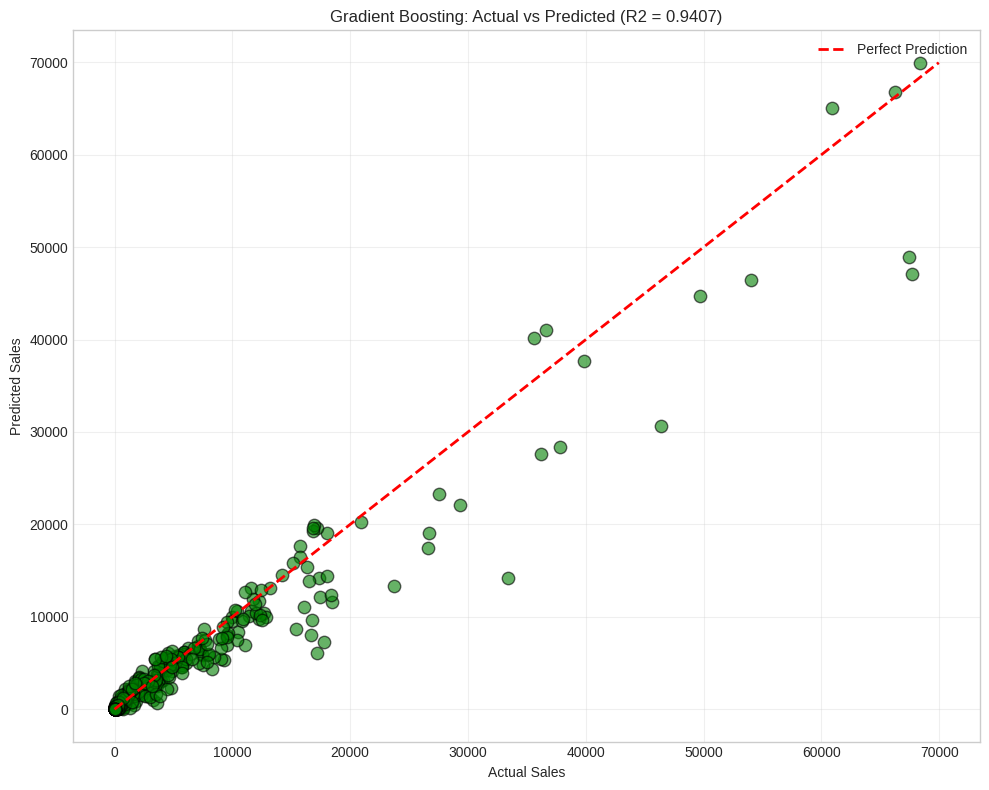

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(y_test, gb_pred, alpha=0.6, edgecolors='black', s=80, color='green')
max_val = max(y_test.max(), max(gb_pred)) if len(y_test) > 0 else 1
ax.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Sales')
ax.set_ylabel('Predicted Sales')
ax.set_title(f'Gradient Boosting: Actual vs Predicted (R2 = {metrics["R2"]:.4f})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

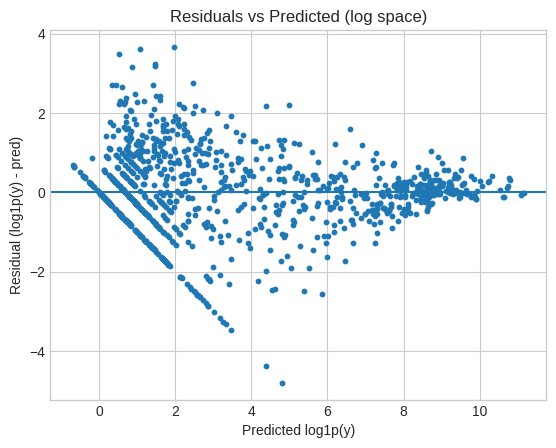

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


y_test_log = np.log1p(y_test)
res = y_test_log - gb_pred_log

plt.figure()
plt.scatter(gb_pred_log, res, s=10)
plt.axhline(0)
plt.xlabel("Predicted log1p(y)")
plt.ylabel("Residual (log1p(y) - pred)")
plt.title("Residuals vs Predicted (log space)")
plt.show()


In [ ]:
import joblib

artifact = {
    "model": gb_model,
    "features": X_train.columns.tolist()
}

joblib.dump(artifact, "gradient_boosting_tertiary_model.pkl")

['gradient_boosting_tertiary_model.pkl']

In [ ]:
X_train.columns.tolist()

['ret_stock',
 'ret_dos',
 'dbr_stock',
 'dbr_dos',
 'wod',
 'stocking_outlet',
 'activating_outlet']

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

print("Starting Hyperparameter Tuning for Gradient Boosting...")

gb = GradientBoostingRegressor(random_state=42)

param_dist = {
    "n_estimators": [200, 300, 400, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05, 0.06, 0.1],
    "max_depth": [3, 4, 5, 6, 7],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

random_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring="neg_mean_squared_error"
)

random_search.fit(X_train, y_train_log)

print("Best Parameters:", random_search.best_params_)

best_gb_model = random_search.best_estimator_

In [ ]:
gb_pred_log = best_gb_model.predict(X_test)

gb_pred = np.expm1(gb_pred_log)
gb_pred = np.clip(gb_pred, 0, None)

metrics = calculate_metrics(y_test, gb_pred, "GradientBoosting_Tuned")

print("Tuned Gradient Boosting trained successfully")

Tuned Gradient Boosting trained successfully


In [ ]:


print("GRADIENT BOOSTING MODEL RESULTS")
print(f"R2 Score:   {metrics['R2']:.4f}")
print(f"MAE:        {metrics['MAE']:.2f}")
print(f"RMSE:       {metrics['RMSE']:.2f}")
print(f"MAPE:       {metrics['MAPE']:.2f}%")
print(f"Accuracy:   {metrics['Accuracy']:.2f}%")


GRADIENT BOOSTING MODEL RESULTS
R2 Score:   0.9868
MAE:        112.40
RMSE:       481.70
MAPE:       9.85%
Accuracy:   90.15%
